# 따릉이 수요 예측 — 벤치마크 시각화
- 데이터: `results/combined_benchmark.csv`
- 그림 ①: 모델별 Asym.RMSE 박스플롯
- 그림 ②: 정류소 × 모델 히트맵
- 그림 ③: 모델별 승률 막대
- 그림 ④: Asym.RMSE vs Under-pred 산점도

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── 데이터 로드 ────────────────────────────────────────────────
ROOT_DIR = Path('..').resolve()
df = pd.read_csv(ROOT_DIR / 'results' / 'combined_benchmark.csv',
                 dtype={'station_id': str})

# 컬럼명 통일
ASYM_COL  = [c for c in df.columns if 'Asym' in c][0]
UNDER_COL = 'Under-pred rate(%)'
RMSE = 'RMSE'

# 모델 순서 고정
MODEL_ORDER = ['SARIMA', 'ARIMAX (temp+rain+weekday)', 'Random Forest',
               'XGBoost', 'XGBoost (alpha=2.0)']
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
color_map = dict(zip(MODEL_ORDER, MODEL_COLORS))

df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
df = df.sort_values(['station_id', 'model'])

print(f'Stations: {df["station_id"].nunique()}')
print(f'Models  : {df["model"].nunique()}')
print(f'Records : {len(df)}')
df.head(10)

Stations: 23
Models  : 5
Records : 115


,station_id,model,RMSE,MAE,Asym.RMSE(alpha=2.0),Under-pred rate(%)
0,02111,SARIMA,0.964,0.757,1.136,31.0
1,02111,ARIMAX (temp+rain+weekday),0.989,0.766,1.224,50.6
2,02111,Random Forest,0.793,0.635,0.992,31.0
3,02111,XGBoost,0.820,0.651,1.033,31.0
4,02111,XGBoost (alpha=2.0),0.886,0.733,1.034,28.0
5,02112,SARIMA,0.731,0.523,0.909,24.4
6,02112,ARIMAX (temp+rain+weekday),0.768,0.566,0.977,49.4
7,02112,Random Forest,0.582,0.474,0.740,25.6
8,02112,XGBoost,0.587,0.465,0.754,25.6
9,02112,XGBoost (alpha=2.0),0.639,0.548,0.746,23.8


## 그림 ① 모델별 Asym.RMSE 박스플롯
> "평일 수요 예측에서 ML이 시계열보다 나은가?"

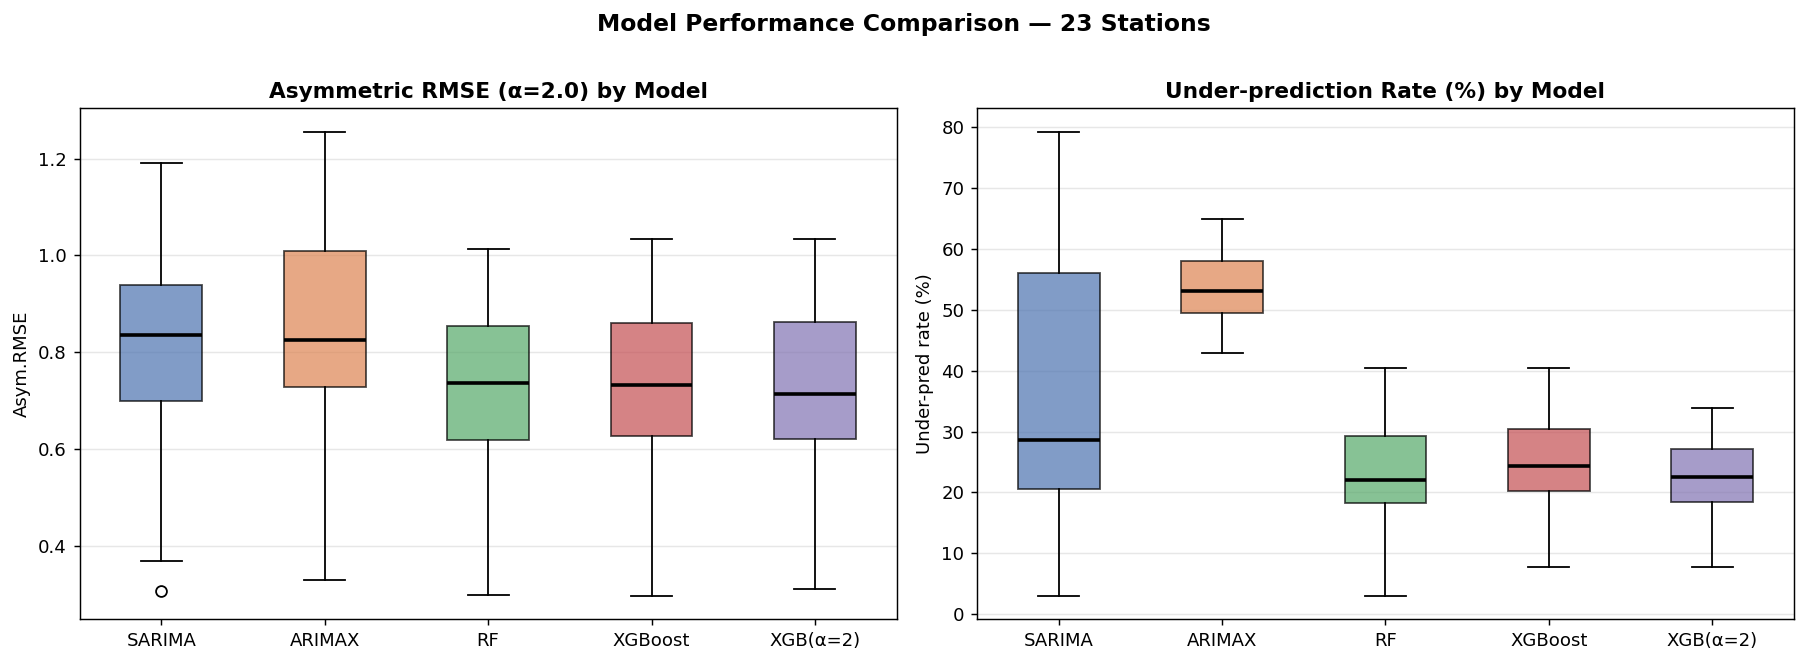

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, ylabel in zip(
    axes,
    [ASYM_COL, UNDER_COL],
    ['Asymmetric RMSE (α=2.0) by Model', 'Under-prediction Rate (%) by Model'],
    ['Asym.RMSE', 'Under-pred rate (%)'],
):
    data = [df[df['model'] == m][metric].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], MODEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(MODEL_ORDER)+1))
    ax.set_xticklabels(['SARIMA', 'ARIMAX', 'RF', 'XGBoost', 'XGB(α=2)'],
                       fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison — 23 Stations',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig1_boxplot.png', bbox_inches='tight')
plt.show()

## 그림 ② 정류소 × 모델 히트맵
> "어느 정류소에서 차이가 크게 나는가?"

/var/folders/pw/tlmw7mpd0lg2r9m2x779s9940000gn/T/ipykernel_76017/4010386606.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='station_id', columns='model',


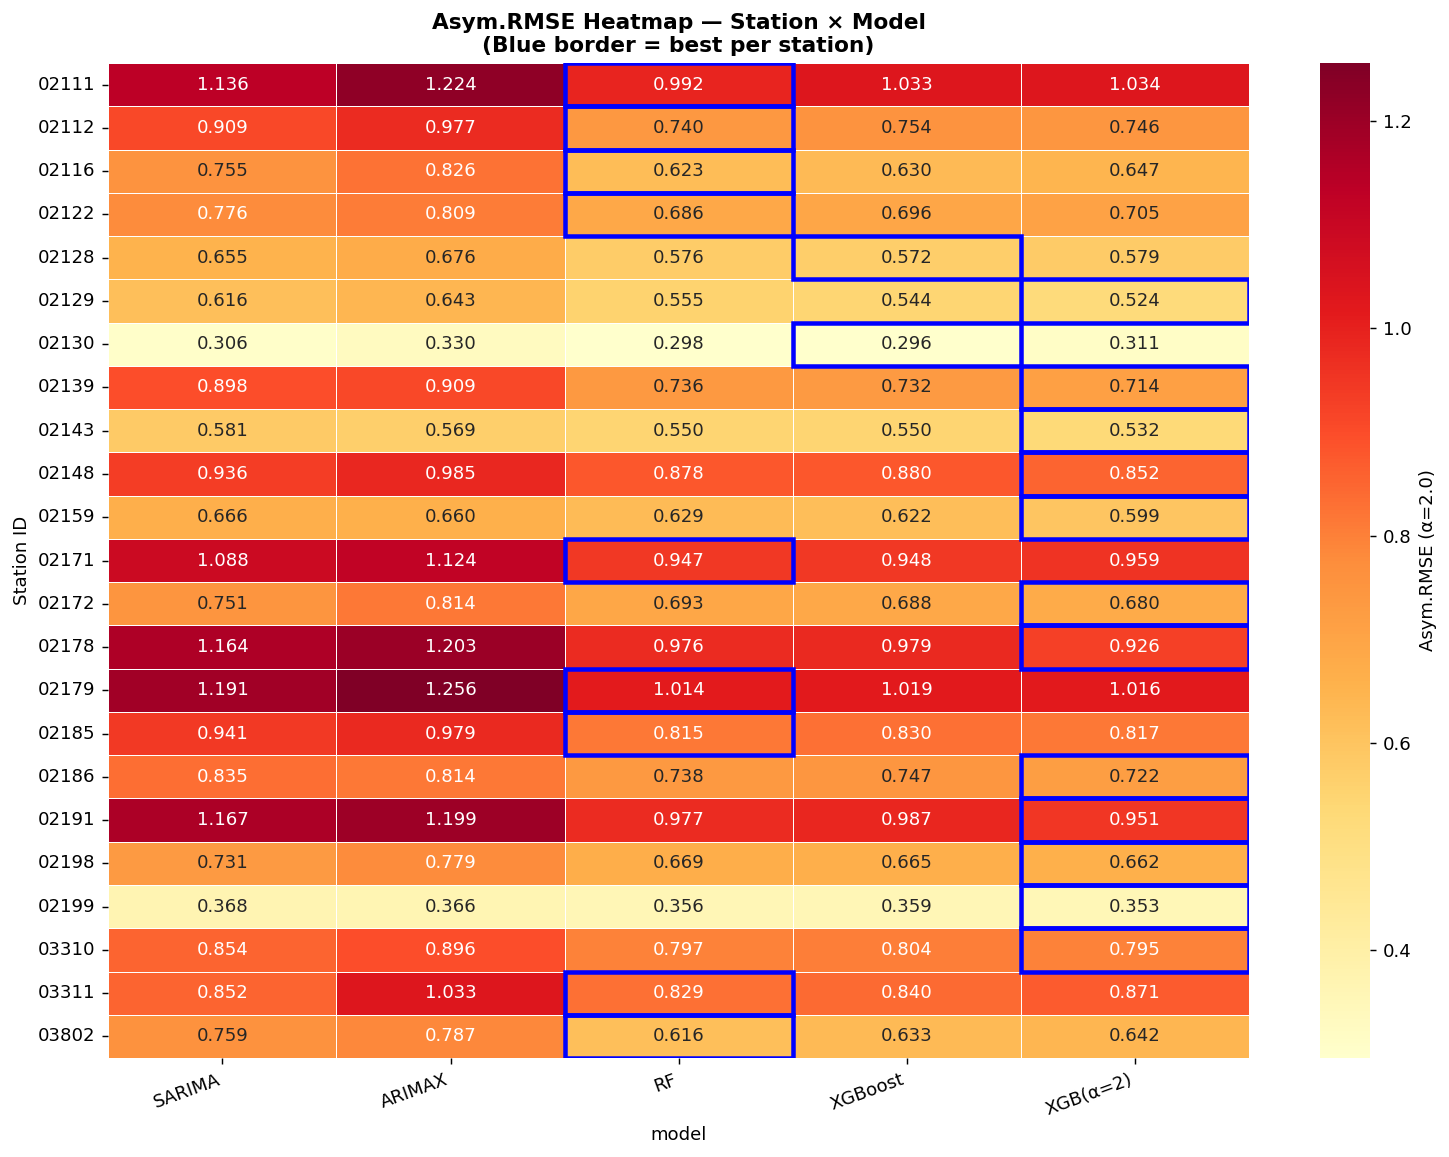

In [49]:
# 피벗
pivot = df.pivot_table(index='station_id', columns='model',
                       values=ASYM_COL, aggfunc='mean')
pivot = pivot[MODEL_ORDER]

# 정류소별 best 모델 마스크
best_mask = pivot.eq(pivot.min(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    pivot, ax=ax,
    cmap='YlOrRd', annot=True, fmt='.3f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Asym.RMSE (α=2.0)'},
)

# best 칸에 테두리
for i, station in enumerate(pivot.index):
    for j, model in enumerate(pivot.columns):
        if best_mask.loc[station, model]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                         fill=False, edgecolor='blue', linewidth=2.5))

ax.set_xticklabels(['SARIMA', 'ARIMAX', 'RF', 'XGBoost', 'XGB(α=2)'],
                   rotation=20, ha='right')
ax.set_ylabel('Station ID')
ax.set_title('Asym.RMSE Heatmap — Station × Model\n(Blue border = best per station)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig2_heatmap.png', bbox_inches='tight')
plt.show()

## 그림 ③ 모델별 승률 막대
> "몇 개 정류소에서 각 모델이 최선이었나?"

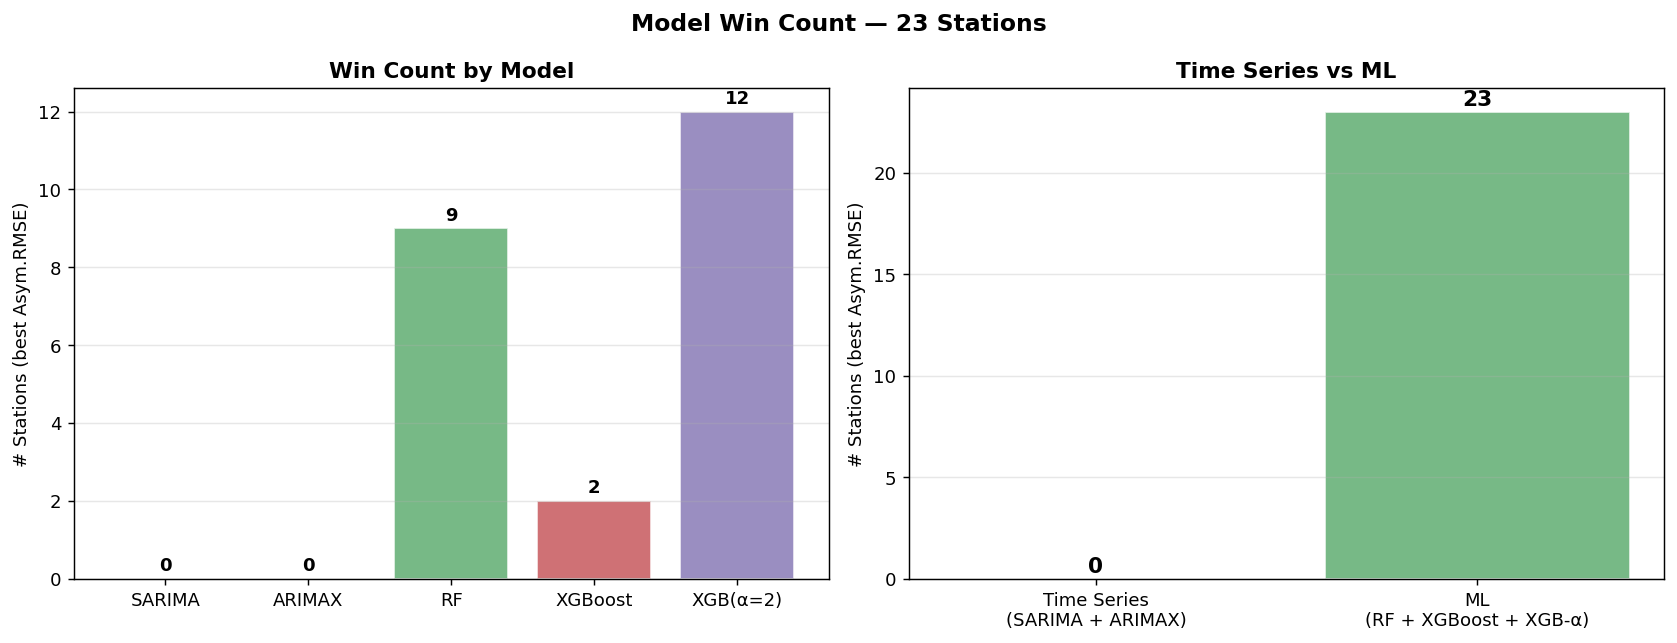


[승률 요약]
SARIMA                         0
ARIMAX (temp+rain+weekday)     0
Random Forest                  9
XGBoost                        2
XGBoost (alpha=2.0)           12


In [50]:
# 정류소별 best 모델
best_model = pivot.idxmin(axis=1)
win_counts = best_model.value_counts().reindex(MODEL_ORDER, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 모델별 승률
ax = axes[0]
bars = ax.bar(range(len(MODEL_ORDER)), win_counts.values,
              color=MODEL_COLORS, alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(['SARIMA', 'ARIMAX', 'RF', 'XGBoost', 'XGB(α=2)'],
                   fontsize=10)
ax.set_ylabel('# Stations (best Asym.RMSE)')
ax.set_title('Win Count by Model', fontsize=12, fontweight='bold')
for bar, val in zip(bars, win_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 시계열 vs ML 2그룹
ax2 = axes[1]
ts_wins = win_counts[['SARIMA', 'ARIMAX (temp+rain+weekday)']].sum()
ml_wins = win_counts[['Random Forest', 'XGBoost', 'XGBoost (alpha=2.0)']].sum()
group_counts = [ts_wins, ml_wins]
group_labels = ['Time Series\n(SARIMA + ARIMAX)', 'ML\n(RF + XGBoost + XGB-α)']
group_colors = ['#4C72B0', '#55A868']
bars2 = ax2.bar(group_labels, group_counts, color=group_colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars2, group_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylabel('# Stations (best Asym.RMSE)')
ax2.set_title('Time Series vs ML', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Model Win Count — 23 Stations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig3_winrate.png', bbox_inches='tight')
plt.show()

print('\n[승률 요약]')
print(win_counts.to_string())

## 그림 ④ RMSE vs Under-pred 산점도
> "정확도는 좋은데 고갈 위험만 높은 모델은?"

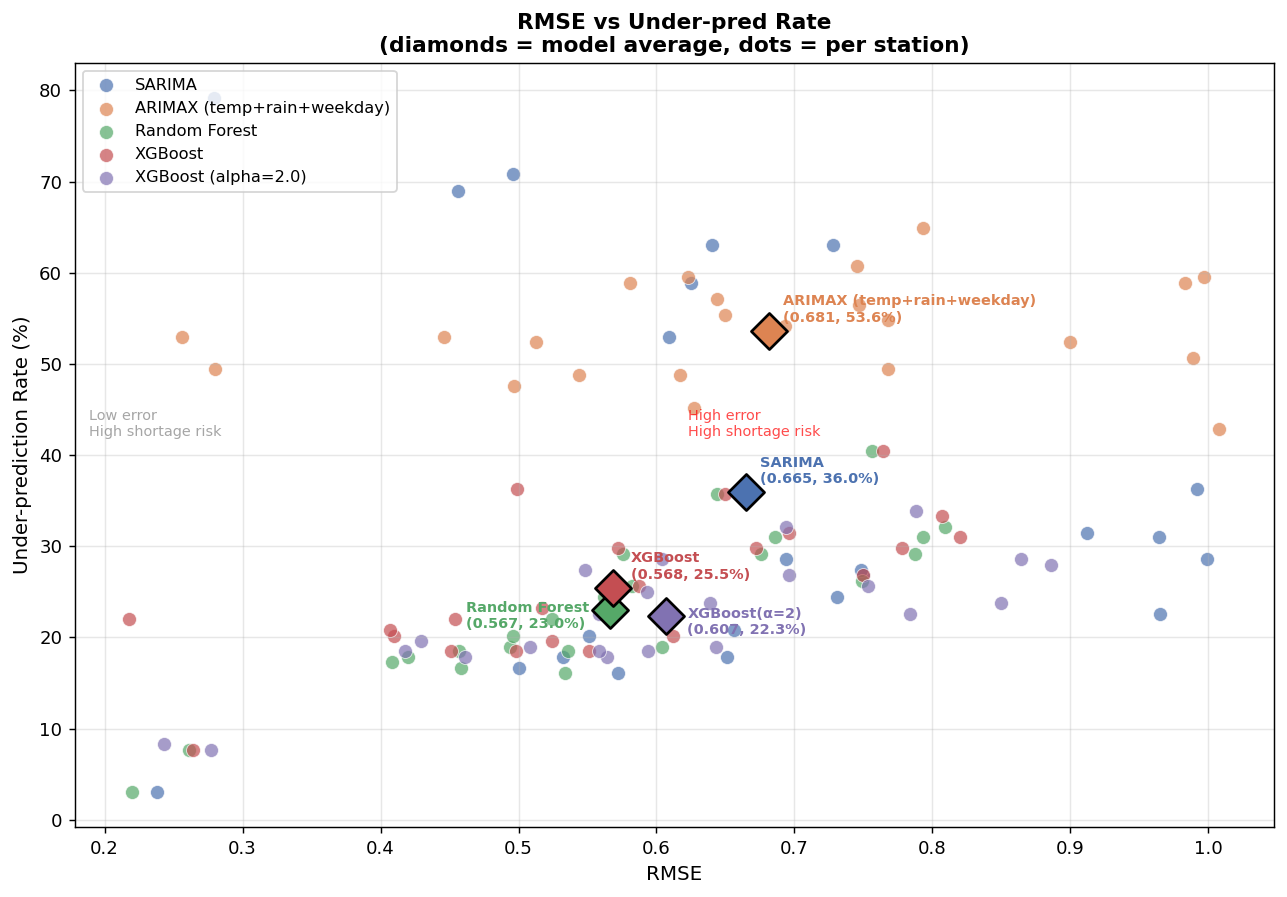

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

for model, color in color_map.items():
    sub = df[df['model'] == model]
    ax.scatter(sub[RMSE], sub[UNDER_COL],
               color=color, alpha=0.7, s=60, label=model, edgecolors='white', linewidth=0.5)

# 모델별 평균 표시
for model, color in color_map.items():
    sub = df[df['model'] == model]
    mx, my = sub[RMSE].mean(), sub[UNDER_COL].mean()

    ax.scatter(
        mx, my,
        color=color,
        s=200,
        marker='D',
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    label = model.replace(' (temp+rain)', '').replace(' (alpha=2.0)', '(α=2)')

    if model == 'Random Forest':
        xytext = (-80, -10)   
    elif model == 'XGBoost':
        xytext = (10, 5)        
    elif model == 'XGBoost (alpha=2.0)':
        xytext = (12, -10) 
    else:
        xytext = (8, 5)

    ax.annotate(
        f'{label}\n({mx:.3f}, {my:.1f}%)',
        (mx, my),
        textcoords='offset points',
        xytext=xytext,
        fontsize=8,
        color=color,
        fontweight='bold'
    )

ax.set_xlabel('RMSE', fontsize=11)
ax.set_ylabel('Under-prediction Rate (%)', fontsize=11)
ax.set_title('RMSE vs Under-pred Rate\n(diamonds = model average, dots = per station)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# 사분면 라벨
xlim, ylim = ax.get_xlim(), ax.get_ylim()
xmid = (xlim[0] + xlim[1]) / 2
ymid = (ylim[0] + ylim[1]) / 2
ax.text(xlim[0]+0.01, ymid+1, 'Low error\nHigh shortage risk', fontsize=8,
        color='gray', alpha=0.7)
ax.text(xmid+0.01, ymid+1, 'High error\nHigh shortage risk', fontsize=8,
        color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig4_scatter.png', bbox_inches='tight')
plt.show()

## 요약 통계

In [52]:
summary = df.groupby('model')[[ASYM_COL, UNDER_COL, 'RMSE', 'MAE']].agg(
    ['mean', 'std']
).round(3)
print('\n[모델별 평균 성능 (23개 정류소)]')
print(summary.to_string())


[모델별 평균 성능 (23개 정류소)]
                           Asym.RMSE(alpha=2.0)        Under-pred rate(%)           RMSE           MAE       
                                           mean    std               mean     std   mean    std   mean    std
model                                                                                                        
SARIMA                                    0.823  0.237             35.952  21.394  0.665  0.209  0.430  0.180
ARIMAX (temp+rain+weekday)                0.863  0.254             53.648   5.413  0.681  0.211  0.480  0.174
Random Forest                             0.726  0.193             23.043   8.723  0.567  0.160  0.421  0.144
XGBoost                                   0.731  0.197             25.465   7.501  0.568  0.162  0.415  0.145
XGBoost (alpha=2.0)                       0.723  0.193             22.335   6.508  0.607  0.173  0.482  0.151


/var/folders/pw/tlmw7mpd0lg2r9m2x779s9940000gn/T/ipykernel_76017/33215630.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('model')[[ASYM_COL, UNDER_COL, 'RMSE', 'MAE']].agg(
